## ⚠️ Warning

This is brute force gaussian blue noise. It has a quadratic complexity on N




## 📦 Install

- pip install numpy matplotlib

small N < 10_000 with jax

- CPU only: pip install jax["cpu"]
- GPU: pip install jax

https://jax.exoplanet.codes/en/latest/tutorials/introduction-to-jax/

big N > 10_000 with KeOps:
- pip install pykeops

https://www.kernel-operations.io/keops/index.html


## 𓂀 With Keops ? It's up to you

In [1]:
with_keops = True

In [2]:
#!pip install pykeops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 11.6 MB/s eta 0:00:00
  Created wheel for pykeops: filename=pykeops-2.3-py3-none-any.whl size=120491 sha256=8c279fc0e0cecf98d8763a5d4f301cdf92020f8b0e4dc68fe7d5923f07634c1b
  Stored in directory: /root/.cache/pip/wheels/b0/ac/34/a732caf88f9754536a4e2389a3f08c035ad33c0ae6f4cfbc38
  Created wheel for keopscore: filename=keopscore-2.3-py3-none-any.whl size=185897 sha256=5032d974d7c4a18060590c07723f06f1c27333db80a7b8f2acdbf3826e84237f
  Stored in directory: /root/.cache/pip/wheels/4f/f8/36/9335901e1bdbd1b6c466d8f33800f66f09c60e457ebc921d29
Successfully built pykeops keopscore


## 📥 Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time
import jax
import jax.numpy as jnp
from jax import lax

if with_keops:
    try:
        from pykeops.numpy import LazyTensor
        nx = np
    except ImportError:
        with_keops = False
        LazyTensor = None
        print("!!! Warning: keops asked but not installed. -> Jax will be used instead")

if not with_keops:
    nx = jnp

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## 🎨 Plot utilities

In [31]:
 def plot(points):
    pts = np.array(points)
    N, D = np.prod(pts.shape[:-1]), pts.shape[-1]

    if D == 2:
        pts = pts[..., :2]
    if D >= 3:
        pts = pts[..., :3]
        D = 3
    pts = pts.reshape(-1, D)

    if N > 30_000:
        ## zooming
        zoom = (30_000/N)**(1.0/D)
        pts = pts[
            (pts <= zoom).all(axis=-1)
        ]

    if D == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=0.4,
            color="black",
        )
    else:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            s=0.4,
            color="black",
        )
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def integers_in_ball(radius, D):
    """3D integer vectors inside a sphere of given radius."""
    if radius <= 1.9:
        #here we don't need to build the grid, wich is crucial in high dimension
        return nx.zeros((0, D), dtype = np.int32) if radius <= 0.9 else np.eye(D, dtype=np.int32)
    r = np.arange(-radius, radius + 1)
    xyz = np.stack(
        np.meshgrid(*(r,) * D, indexing="ij"), axis=-1
    ).reshape(-1, D)
    xyz_len = np.sum(xyz ** 2, axis=-1)
    return xyz[(xyz_len > 0) & (xyz_len <= radius ** 2)]

def structure_factor(
    points,
    bins = 100,
    resolution=1,
):
    """ structure factor estimated through scattering intensity """
    pts = np.asarray(points)
    N, D = pts.shape

    kmed = int(1000**(1/D))
    kmax = int(2 * N**(1.0/D))

    bins = np.linspace(0, kmax, bins)
    n_bins = len(bins) - 1

    nvecs = np.random.randint(
        -kmax,
        kmax + 1,
        size=(int(resolution*1000), D),
    )

    nvecs = np.concatenate(
        [nvecs, integers_in_ball(kmed, D)],
        axis=0,
    )

    nvecs = nvecs[np.any(nvecs != 0, axis=1)]

    knorm = np.linalg.norm(nvecs, axis=1)

    bin_idx = np.searchsorted(bins, knorm) - 1

    valid = (bin_idx >= 0) & (bin_idx < n_bins)
    nvecs   = nvecs[valid]
    bin_idx = bin_idx[valid]

    kvecs = 2.0 * np.pi * nvecs

    pts   = jnp.array(pts)
    kvecs = jnp.array(kvecs)

    def compute_Sk(k):
        rho = jnp.sum(jnp.exp(1j * (pts @ k)), axis=0)
        return jnp.abs(rho) ** 2 / N

    Sk = jax.lax.map(compute_Sk, kvecs)

    Sk = np.asarray(Sk)

    S = np.bincount(bin_idx, weights=Sk, minlength=n_bins)
    C = np.bincount(bin_idx,             minlength=n_bins)

    valid = C > 0
    S = S[valid] / C[valid]
    k = (0.5 * (bins[:-1] + bins[1:]))[valid]

    return k, S


def plot_sf(x, bins = 100, resolution = 1):
    x = x.reshape(-1, x.shape[-1])

    ks, vals = structure_factor(x)

    plt.figure()
    plt.loglog(ks, vals, marker="o", markersize=2, linewidth=1)
    plt.xlabel("k"); plt.ylabel("S(k)")
    plt.title("Structure factor (log-log)")
    plt.grid(True, which="both"); plt.tight_layout(); plt.show()

## 🏭 Optimizaton pipeline

In [78]:
def _make_hyperparams(N, D, nx):
    """Shared hyperparameter logic."""
    DX = 1 / N ** (1.0 / D)
    S = 1
    sigma2 = S * 2 * DX ** 2
    high_dimension_regime = sigma2 >= 0.03

    if D <= 2:   lr = 0.4
    elif D == 3: lr = 0.1
    elif D == 4: lr = 0.05
    elif D == 5: lr = 0.02
    else:        lr = 0.01

    Niter = 10_000 if not high_dimension_regime else 1_000

    a_ = 2.0 * nx.pi
    b_ = 2.0 / (sigma2 * a_ ** 2)
    c_ = 1.0 / (2 * S * nx.pi)

    return sigma2, lr, Niter, high_dimension_regime, a_, b_, c_


def _make_kernels(sigma2, high_dimension_regime, a_, b_, c_, nx):
    """Build pacman + both kernels, return the selected one."""

    if nx == jnp:
        def sum_last_axis(x):
            return jnp.sum(x, axis=-1, keepdims = True)
        exp_func = jnp.exp
        cos_func = jnp.cos
        sin_func = jnp.sin
        floor_func = jnp.floor
    else: # nx == np (for KeOps)
        def sum_last_axis(x):
            return x.sum(axis=-1)
        def keops_exp(x):
            return x.exp()
        def keops_cos(x):
            return x.cos()
        def keops_sin(x):
            return x.sin()
        def floor(x):
            return 1.0*(x > 1.0) - 1.0*(x < 0.0)
        exp_func = keops_exp
        cos_func = keops_cos
        sin_func = keops_sin
        floor_func = floor

    def pacman(x):
        return x - floor_func(x)

    def gaussian_kernel(x, y):
        delta = pacman(y - x + 0.5) - 0.5
        dist2 = sum_last_axis(delta ** 2)
        return delta * exp_func(-dist2 / sigma2)

    def gaussian_sinus_kernel(x, y):
        delta = a_ * (y - x)
        cos_term = b_ * (1.0 - cos_func(delta))
        sin_term = c_ * sin_func(delta)
        dist2 = sum_last_axis(cos_term)
        return sin_term * exp_func(-dist2)

    print("available kernels [gaussian / gaussian_sine]")

    if high_dimension_regime:
        print(f"selected [gaussian_sine] as sigma2={sigma2:.3f} >= 0.03")
        return pacman, gaussian_sinus_kernel
    else:
        print(f"selected [gaussian] as sigma2={sigma2:.3f} < 0.03")
        return pacman, gaussian_kernel


# ───────────────────
#  JAX pipeline  (brute-force O(N²) memory)
# ───────────────────
def make_pipeline_jax(N, D):
    sigma2, lr, Niter, high_dim, a_, b_, c_ = _make_hyperparams(N, D, jnp)
    pacman, kernel = _make_kernels(sigma2, high_dim, a_, b_, c_, jnp)

    def grad(x):
        return kernel(x[:, None], x[None, :]).sum(axis=1)

    @jax.jit
    def run_n_steps(x):
        def step(i, x):
            return pacman(x - lr * grad(x))
        return jax.lax.fori_loop(0, Niter, step, x)

    print("Compiling pipeline...")
    compiled_run = run_n_steps.lower(
        jax.ShapeDtypeStruct((N, D), jnp.float32)
    ).compile()
    print("Done. Pipeline ready.")

    def sample(init=None):
        """Sample a stealthy point pattern. Best for N ≤ 3000."""
        if init is None:
            init = np.random.rand(N, D)
        init = jnp.asarray(init)
        result = compiled_run(init)
        result.block_until_ready()
        return result

    return sample


# ───────────────────
#  KeOps pipeline  (O(N) memory, large N)
# ───────────────────
def make_pipeline_keops(N, D):
    sigma2, lr, Niter, high_dim, a_, b_, c_ = _make_hyperparams(N, D, np)
    pacman, kernel = _make_kernels(sigma2, high_dim, a_, b_, c_, np)

    def lazy_grad(x):
        x = np.asarray(x)
        x_i = LazyTensor(x[:, None, :])  # (N,1,D)
        x_j = LazyTensor(x[None, :, :])  # (1,N,D)
        return kernel(x_i, x_j).sum(axis=1)

    print("Compiling pipeline...")
    lazy_grad(np.random.rand(N, D))
    print("Done. Pipeline ready.")

    def run_n_steps(x):
        for i in range(Niter):
            x = pacman(x - lr * lazy_grad(x))
        return x


    def sample(init=None):
        """Sample a stealthy point pattern, up to N<= 10_000/20_000"""
        if init is None:
            init = np.random.rand(N, D).astype(np.float32)
        return run_n_steps(init)

    return sample


# ───────────────────
#  Backend Dispatch
# ───────────────────
def make_pipeline(N, D, backend = "auto"):
    print("available backend [JAX / KeOps]")
    if backend == "auto":
        if with_keops and N > 5_000:
            print(f"selected [KeOPs] as N > 5_000")
            return make_pipeline_keops(N, D)
        if N < 5_000:
            print(f"selected [JAX] as N < 5_000")
        if not with_keops and N > 5_000:
            print(f"selected [JAX] as KeOps is unavailable")
        return make_pipeline_jax(N, D)
    if backend == "JAX":
        print(f"selected [JAX] as backend")
        return make_pipeline_jax(N, D)
    if backend == "KeOps":
        print(f"selected [KeOps] as backend")
        return make_pipeline_keops(N, D)
    raise ValueError(f"unknown backend {backend}, must be [auto JAX or KeOps]")

## 🏁 Entry point:

- N: number of points \
DON'T go beyond **a few thousand points** because brute_force has quadratic complexity

- D: dimension of the points \
feel free to go **up to dimension 100**

In [84]:
N = 500
D = 4

pipeline = make_pipeline(N, D)

available backend [JAX / KeOps]
selected [JAX] as N < 5_000
available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.089 >= 0.03
Compiling pipeline...
Done. Pipeline ready.


## 🔥 Let's go !

In [85]:
Poisson = np.random.rand(N, D)
start = time.time()
stealthy_points = pipeline(init = Poisson)
end = time.time()
print(f"stealthy points ready (runtime {(end-start):.1f} s)")

stealthy points ready (runtime 12.3 s)


## 🖼️ Result

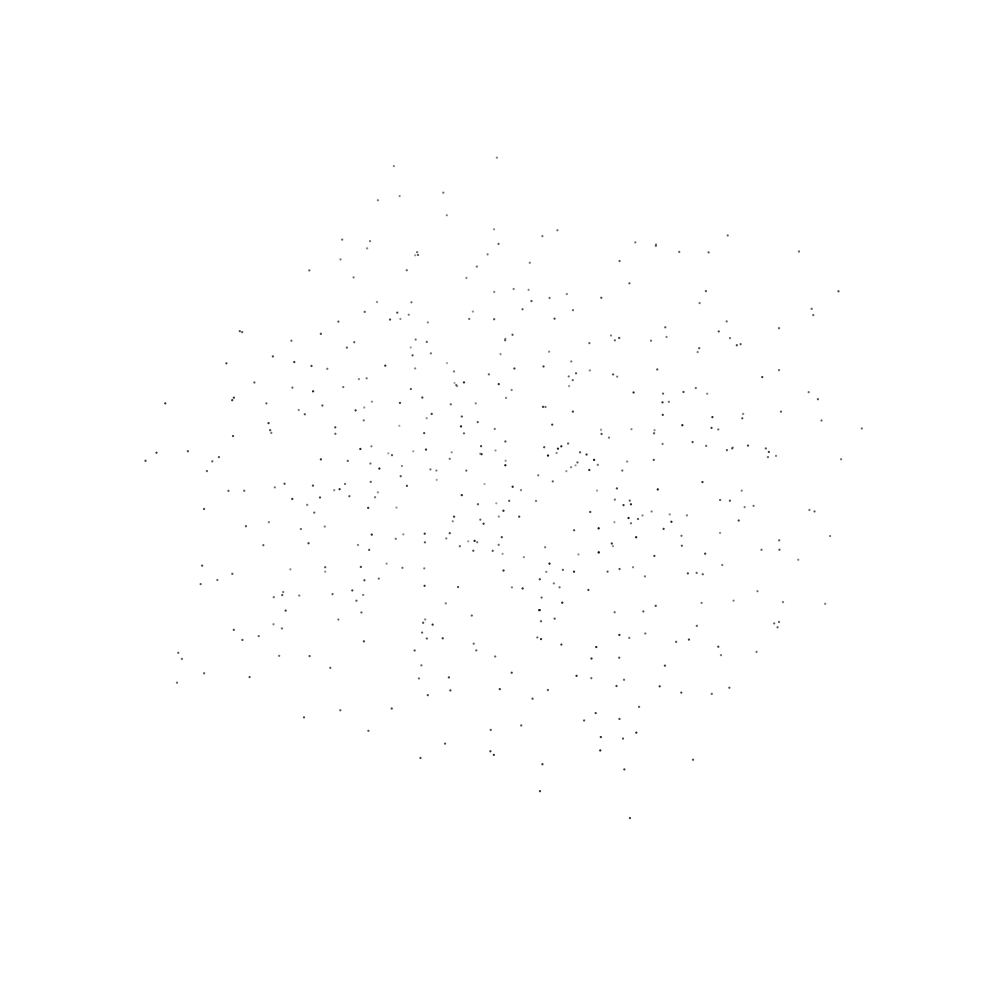

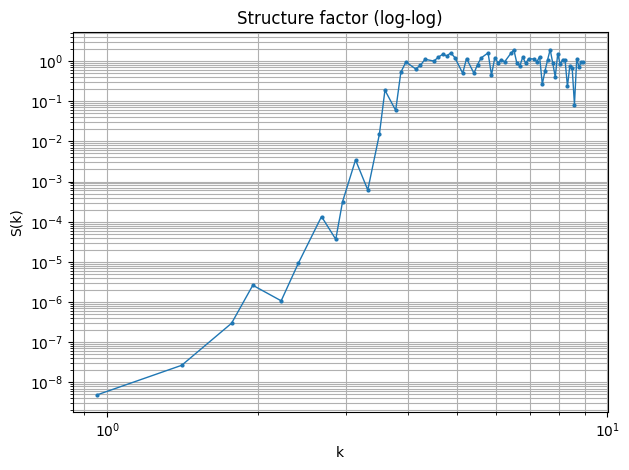

In [86]:
if D <= 4:
    plot(stealthy_points)
plot_sf(stealthy_points, bins = 100, resolution = 1)